In [1]:
import sys

In [2]:
sys.path.append("/home/gputnam/Diffusion-Anomaly-Detection/diffusion-anomaly")

In [3]:
from guided_diffusion.script_util import (
    model_and_diffusion_defaults,
    diffusion_defaults,
    create_model_and_diffusion,
    args_to_dict,
    add_dict_to_argparser,
    create_gaussian_diffusion
)

from guided_diffusion.resample import UniformSampler
from guided_diffusion import dist_util

from guided_diffusion.fp16_util import *

from guided_diffusion.respace import space_timesteps

import numpy as np
import matplotlib.pyplot as plt
import torch as th

import h5py

import os

import pickle

Setting up a new session...
/home/gputnam/Diffusion-Anomaly-Detection/diffusion-anomaly/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Setting up a new session...


In [4]:
plt.rcParams.update({'font.size': 14})

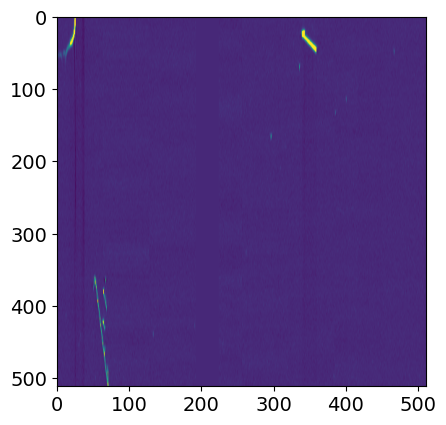

In [5]:
fname = "/scratch/7DayLifetime/munjung/anomaly-detection-raw-h5/results-interesting/83487027_0/g4-raw-0_1-woclass-ddpm.pkl"

with open(fname, "rb") as f:
    d = pickle.load(f)

undershoot = d[39]["original"].T

plt.imshow(undershoot)

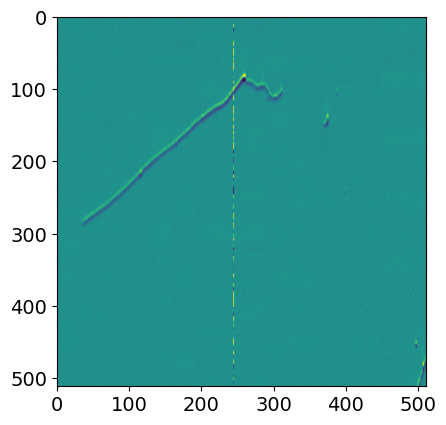

In [6]:
# BAD DATA IMAGE
fname = "/scratch/7DayLifetime/munjung/anomaly-detection-raw-h5/run_18515_sub_1_evt_29363/results-grayNN-ddim/g4-raw-1.pkl"

with open(fname, "rb") as f:
    d = pickle.load(f)

bad_wire = d[29]["original"].T

plt.imshow(bad_wire)

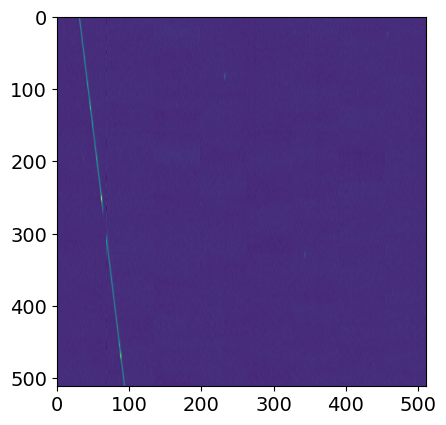

In [84]:
fname = "/scratch/7DayLifetime/munjung/anomaly-detection-raw-h5/results-interesting/83487027_0/g4-raw-0_1-woclass-ddpm.pkl"

with open(fname, "rb") as f:
    d = pickle.load(f)

dead_wires = d[323]["original"].T

dead_wires[:, 64:68] = 0

plt.imshow(dead_wires)

In [85]:
imgs = np.expand_dims(np.stack([undershoot, bad_wire, dead_wires]), axis=1)
imgs = th.tensor(imgs, device=dist_util.dev())

In [86]:
th.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [87]:
args = model_and_diffusion_defaults()
diffusion_args = diffusion_defaults()

In [88]:
# MODEL
args["image_size"] = 512
args["num_channels"] = 32
args["class_cond"] = False
args["num_res_blocks"] = 2
args["num_heads"] = 8
args["learn_sigma"] = True
args["use_scale_shift_norm"] = False
args["attention_resolutions"] = "16,32"
args["channel_mult"] = "1,2,4,8,8,8"

# DIFFUSION
diffusion_args["diffusion_steps"] = 1000
diffusion_args["noise_schedule"] = "linear"
diffusion_args["rescale_learned_sigmas"] = False
diffusion_args["rescale_timesteps"] = False

diffusion_args.pop("diffusion_steps")
diffusion_args.pop("timestep_respacing")

# TODO: change?
diffusion_args["learn_sigma"] = True

args = args | diffusion_args

In [89]:
model, diffusion = create_model_and_diffusion(**args)

timestepresp1 
numberinchannels 1
steps 1000 [1000]
predict_xstart False
predict_xprev False
model_mean_type ModelMeanType.EPSILON
num_timesteps 1000
sectioncount [1000]
all steps {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185,

In [90]:
MODEL = "/exp/sbnd/data/users/gputnam/training-SBND/iterE/results/brats2update111000.pt"

In [91]:
model.load_state_dict(
    dist_util.load_state_dict(MODEL, map_location="cpu")
)

model.to(dist_util.dev())
_ = model.eval()

In [92]:
T = 100

In [93]:
ddim_noisef = diffusion.ddim_sample_loop_progressive(model, imgs.shape, time=T, noise=imgs, 
                                             reverse=True, progress=True)

ddim_noise = list(ddim_noisef)

100%|██████████| 99/99 [00:32<00:00,  3.06it/s]


In [94]:
ddim_noised = ddim_noise[-1]["sample"]

In [95]:
rand_noised = diffusion.q_sample(imgs, th.tensor(T, device=dist_util.dev()))

In [96]:
ddim_2_ddim = diffusion.ddim_sample_loop_progressive(model, 
                imgs.shape, time=T, noise=ddim_noised, progress=True)

rand_2_ddim = diffusion.ddim_sample_loop_progressive(model, 
                imgs.shape, time=T, noise=rand_noised, progress=True)

ddim_2_ddpm = diffusion.p_sample_loop_progressive(model, 
                imgs.shape, time=T, noise=ddim_noised, progress=True)

rand_2_ddpm = diffusion.p_sample_loop_progressive(model, 
                imgs.shape, time=T, noise=rand_noised, progress=True)



In [97]:
ddim_2_ddim_reco = list(ddim_2_ddim)[-1]["sample"]
rand_2_ddim_reco = list(rand_2_ddim)[-1]["sample"]
# ddim_2_ddpm_reco = list(ddim_2_ddpm)[-1]["sample"]
rand_2_ddpm_reco = list(rand_2_ddpm)[-1]["sample"]

100%|██████████| 100/100 [00:32<00:00,  3.06it/s]


In [98]:
recos = [
    ddim_2_ddim_reco,
    rand_2_ddim_reco,
    # ddim_2_ddpm_reco,
    rand_2_ddpm_reco
]

In [99]:
titles = [
    "Shower Undershoot",
    "Bad Wire",
    "Dead Wires",
]

reco_names = [
    "DDIM to DDIM",
    "Random to DDIM",
    # "DDIM to DDPM",
    "Random to DDPM",
]

<Figure size 640x480 with 0 Axes>

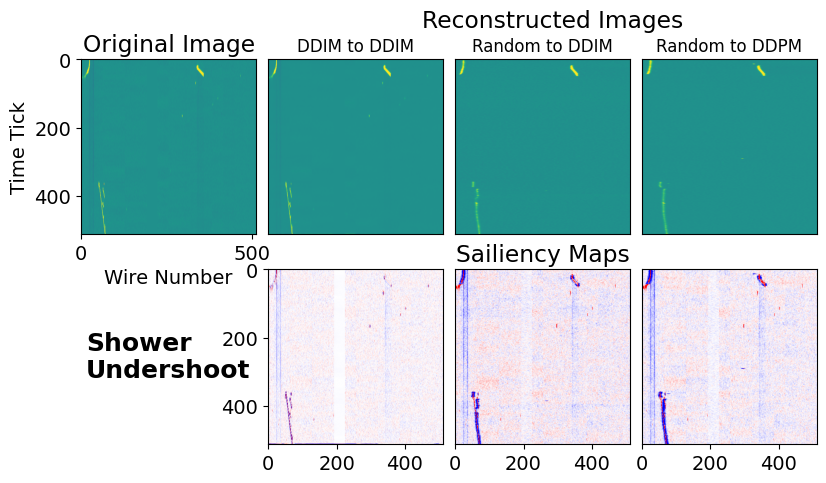

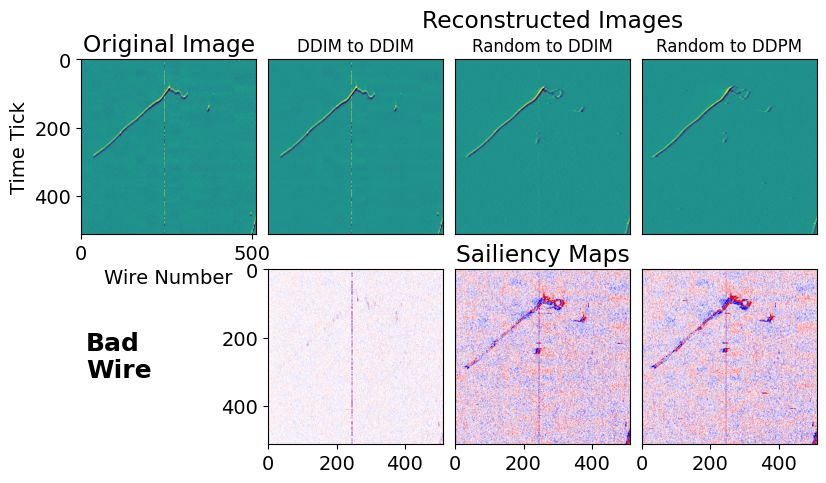

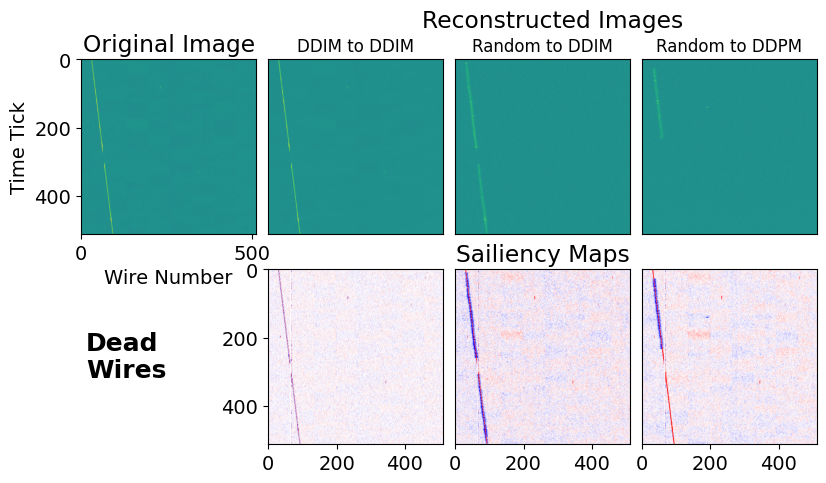

In [100]:
for ifig, title in enumerate(titles):
    plt.figure(ifig)
    fig, axs = plt.subplots(2, 4, figsize=(9.6,5))

    axs[0][0].set_title("Original Image")
    axs[0][0].imshow(np.squeeze(imgs[ifig].cpu().numpy()), vmin=-0.5, vmax=0.5)
    axs[1][0].axis('off')

    axs[1][0].text(0.05, 0.5, title.replace(" ", "\n"), horizontalalignment="left", 
                   verticalalignment="center", fontsize=18, fontweight="bold")
    
    for ireco, rname in enumerate(reco_names):
        axs[0][ireco+1].imshow(np.squeeze(recos[ireco][ifig].cpu().numpy()), vmin=-0.5, vmax=0.5)
        axs[1][ireco+1].imshow(np.squeeze((imgs[ifig] - recos[ireco][ifig]).cpu().numpy()), vmin=-0.1, vmax=0.1, cmap="bwr")
        
        axs[0][ireco+1].set_xticks([])
        axs[0][ireco+1].set_yticks([])
        
        if ireco > 0:
            axs[1][ireco+1].set_yticks([])
            
        axs[0][ireco+1].set_title(rname, fontsize=12)
            
    fig.subplots_adjust(wspace=0.02, hspace=0.2) # Make room on the right
    fig.suptitle("Reconstructed Images", x=0.62)
    axs[1][2].set_title("Sailiency Maps")
    
    axs[0][0].set_xlabel("Wire Number")
    axs[0][0].set_ylabel("Time Tick")